In [45]:
import os
import torchaudio
import csv
from torch.utils.data import Dataset
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as T
from IPython.display import Audio

In [2]:
#Create folder FIRST
os.makedirs("data", exist_ok=True)

# Download dataset
dataset = torchaudio.datasets.LJSPEECH(
    root="data",
    download=True
)

print("Dataset downloaded successfully!")

100%|██████████| 2.56G/2.56G [00:24<00:00, 112MB/s]


Dataset downloaded successfully!


In [28]:
class MyLJSpeech(Dataset):
    def __init__(self, root):
        self.dataset_path = os.path.join(root, "LJSpeech-1.1")
        self.wav_path = os.path.join(self.dataset_path, "wavs")
        self.metadata_path = os.path.join(self.dataset_path, "metadata.csv")

        with open(self.metadata_path, "r", encoding="utf-8") as f:
            reader = csv.reader(f, delimiter="|")
            self.data = list(reader)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]

        file_id = row[0]
        text = row[1]   # ONLY 2 columns

        wav_file = os.path.join(self.wav_path, file_id + ".wav")

        waveform, sample_rate = torchaudio.load(wav_file)

        return waveform, sample_rate

CREATE DATASET

In [29]:
dataset = MyLJSpeech("data")

print("Total samples:", len(dataset))

Total samples: 13100


In [30]:
waveform, sr = dataset[0]
print(waveform.shape, sr)

torch.Size([1, 212893]) 22050


MEL SPECTROGRAM

In [6]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=22050,
    n_fft=1024,
    hop_length=256,
    n_mels=80
)

db_transform = torchaudio.transforms.AmplitudeToDB()

def waveform_to_mel(waveform):
    return db_transform(mel_transform(waveform))

In [31]:
train_dataset = SpeechDataset(dataset)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

ADD NOISE

In [32]:
def add_noise(waveform, noise_level=0.05):
    noise = torch.randn_like(waveform)
    return waveform + noise_level * noise

TRAINING DATASET

In [33]:
class SpeechDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        waveform, sr = self.base_dataset[idx]

        noisy_waveform = add_noise(waveform)

        clean = waveform_to_mel(waveform)
        noisy = waveform_to_mel(noisy_waveform)

        clean = fix_length(clean)
        noisy = fix_length(noisy)

        return noisy, clean

DATALOADER

In [34]:
train_dataset = SpeechDataset(dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

print("DataLoader ready")

DataLoader ready


In [35]:
noisy, clean = next(iter(train_loader))
print(noisy.shape)

torch.Size([8, 1, 80, 800])


U-NET MODEL

In [36]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU()
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU()
        )

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(x1)

        x3 = self.bottleneck(x2)

        x4 = self.dec1(x3)
        x5 = self.dec2(x4)

        return self.out(x5)

TRAIN SETUP

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [38]:
MAX_LEN = 800   # you can change (important)

def fix_length(mel):
    if mel.shape[2] < MAX_LEN:
        # Pad
        pad_size = MAX_LEN - mel.shape[2]
        mel = F.pad(mel, (0, pad_size))
    else:
        # Trim
        mel = mel[:, :, :MAX_LEN]
    return mel

In [39]:
def __getitem__(self, idx):
    row = self.data[idx]

    file_id = row[0]
    text = row[1]   # only 2 columns

    wav_file = os.path.join(self.wav_path, file_id + ".wav")

    waveform, sample_rate = torchaudio.load(wav_file)

    return waveform, sample_rate

TRAIN MODEL

In [40]:
epochs = 3

for epoch in range(epochs):
    model.train()   # IMPORTANT
    total_loss = 0

    for noisy, clean in train_loader:

        # Move to device
        noisy = noisy.to(device).float()
        clean = clean.to(device).float()

        # Forward pass
        output = model(noisy)

        # Loss
        loss = criterion(output, clean)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 106.2394
Epoch 2/3, Loss: 77.7137
Epoch 3/3, Loss: 74.3656


Convert Spectrogram → Audio

In [42]:
# Inverse Mel Spectrogram
inverse_mel = T.InverseMelScale(
    n_stft=513,
    n_mels=80,
    sample_rate=22050
)

# Griffin-Lim (reconstruct waveform)
griffin_lim = T.GriffinLim(n_fft=1024)

Convert output → waveform

In [43]:
def mel_to_audio(mel_spec):
    mel_spec = torch.exp(mel_spec)  # undo log (approx)
    spec = inverse_mel(mel_spec)
    waveform = griffin_lim(spec)
    return waveform

Test model output

In [44]:
noisy, clean = train_dataset[0]

model.eval()
with torch.no_grad():
    output = model(noisy.unsqueeze(0).to(device))

output = output.squeeze().cpu()

# Convert to audio
audio = mel_to_audio(output)

# Save audio
torchaudio.save("enhanced.wav", audio.unsqueeze(0), 22050)
print("Saved enhanced.wav")

Saved enhanced.wav


In [46]:
Audio("enhanced.wav")

In [48]:
# Save clean
clean_waveform, _ = dataset[0]

torchaudio.save("clean.wav", clean_waveform, 22050)

from IPython.display import Audio
Audio("clean.wav")

Spectrogram Visualization

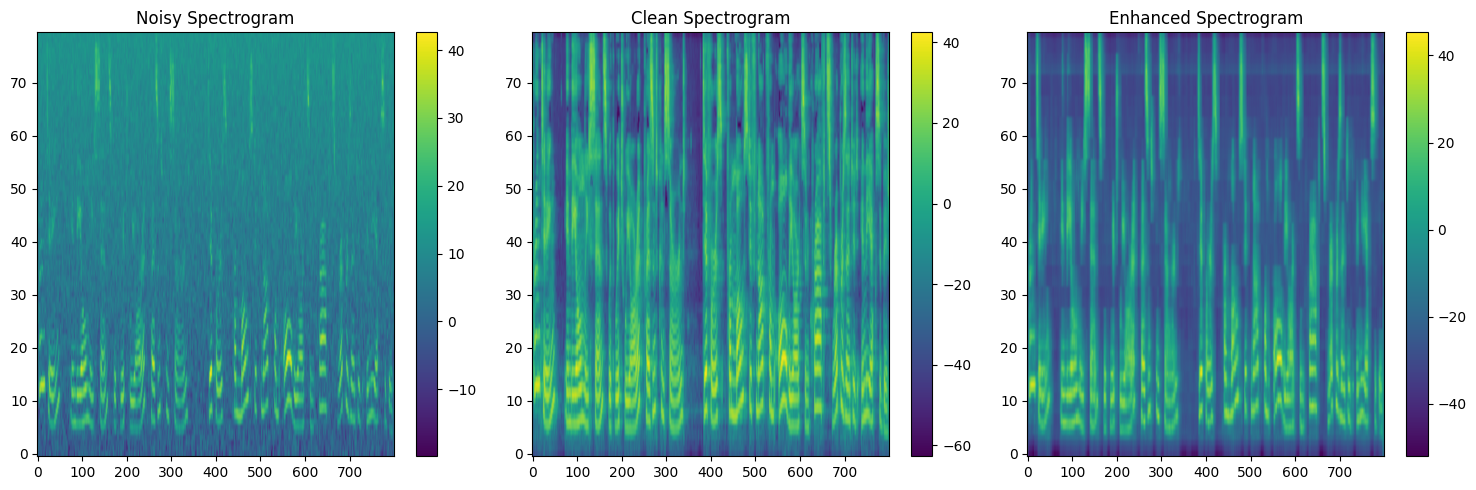

In [52]:
import matplotlib.pyplot as plt

# Get sample
noisy, clean = train_dataset[0]

# Model output
model.eval()
with torch.no_grad():
    output = model(noisy.unsqueeze(0).to(device)).cpu().squeeze()

# Convert to numpy for plotting
noisy_np = noisy.squeeze().numpy()
clean_np = clean.squeeze().numpy()
output_np = output.numpy()

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Noisy Spectrogram")
plt.imshow(noisy_np, aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Clean Spectrogram")
plt.imshow(clean_np, aspect='auto', origin='lower')
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Enhanced Spectrogram")
plt.imshow(output_np, aspect='auto', origin='lower')
plt.colorbar()

plt.tight_layout()
plt.show()

Waveform Visualization (Time Domain)

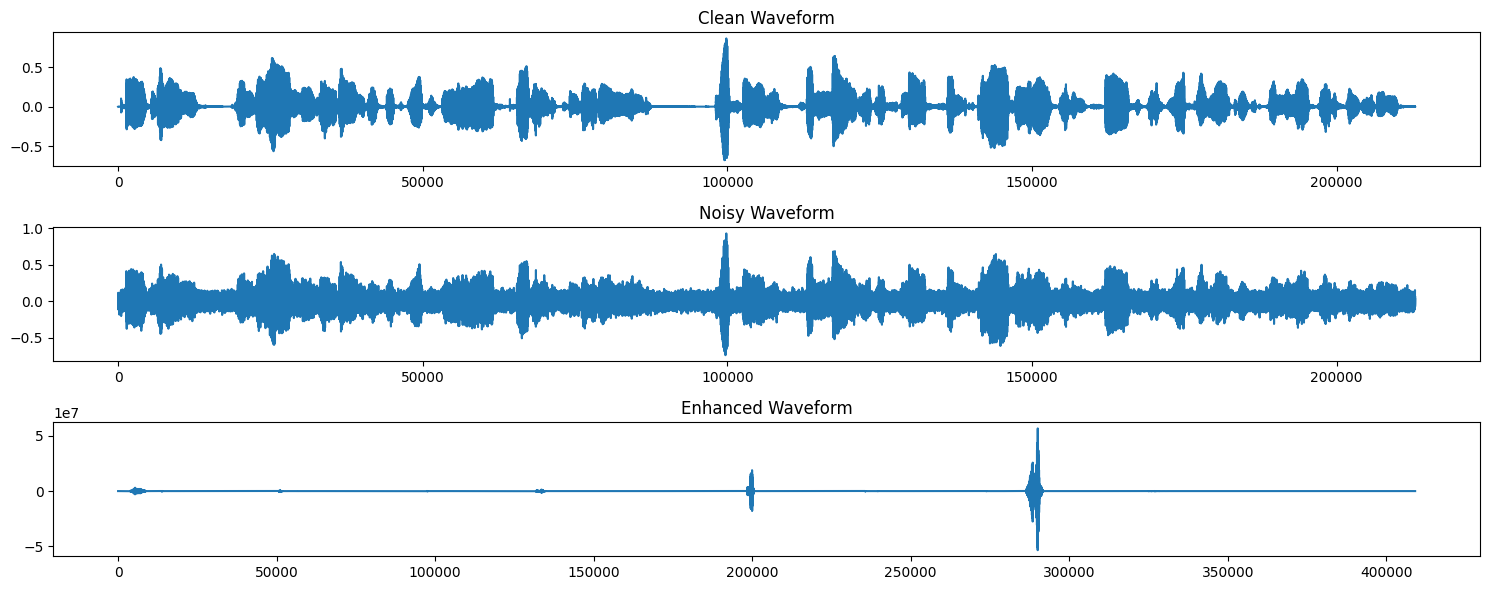

In [53]:
# Get waveform
waveform, _ = dataset[0]
noisy_waveform = add_noise(waveform)

# Enhanced waveform
enhanced_audio = mel_to_audio(output)

# Convert to numpy
clean_wav = waveform.squeeze().numpy()
noisy_wav = noisy_waveform.squeeze().numpy()
enhanced_wav = enhanced_audio.squeeze().numpy()

# Plot
plt.figure(figsize=(15,6))

plt.subplot(3,1,1)
plt.title("Clean Waveform")
plt.plot(clean_wav)

plt.subplot(3,1,2)
plt.title("Noisy Waveform")
plt.plot(noisy_wav)

plt.subplot(3,1,3)
plt.title("Enhanced Waveform")
plt.plot(enhanced_wav)

plt.tight_layout()
plt.show()

SNR METRIC

In [49]:
def compute_snr(clean, noisy):
    noise = clean - noisy
    snr = 10 * torch.log10(torch.sum(clean**2) / torch.sum(noise**2))
    return snr.item()

Evaluate model

In [50]:
noisy, clean = train_dataset[0]

model.eval()
with torch.no_grad():
    output = model(noisy.unsqueeze(0).to(device)).cpu().squeeze()

snr_before = compute_snr(clean, noisy)
snr_after = compute_snr(clean, output)

print("SNR before:", snr_before)
print("SNR after:", snr_after)

SNR before: -1.5827841758728027
SNR after: 6.058380126953125


Save Model

In [51]:
torch.save(model.state_dict(), "unet_speech.pth")
print("Model saved!")

Model saved!
